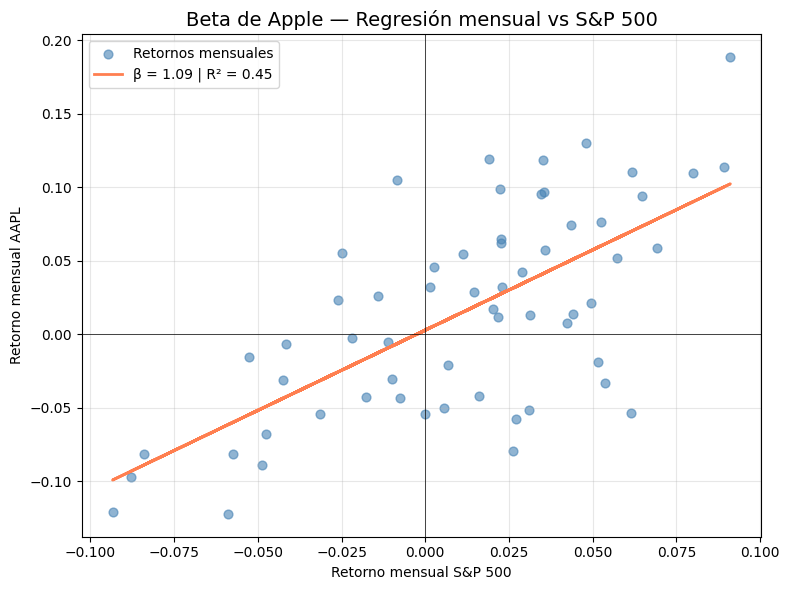

In [1]:
#| label: fig-beta
#| fig-cap: "Beta de Apple: regresión de los retornos mensuales frente al S&P 500 (últimos 60 meses)."
#| echo: false
import sys
sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from src.yahoo_client import fetch_monthly_returns

START, END = '2020-01-01', '2025-12-31'
mkt  = fetch_monthly_returns('^GSPC', start=START, end=END)
aapl = fetch_monthly_returns('AAPL',  start=START, end=END)
df = aapl.join(mkt['return'], rsuffix='_mercado').dropna().tail(60)

slope, intercept, r_value, p_value, std_err = stats.linregress(df['return_mercado'], df['return'])
x = df['return_mercado']
y_pred = slope * x + intercept

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, df['return'], alpha=0.6, color='steelblue', s=40, label='Retornos mensuales')
ax.plot(x, y_pred, color='coral', linewidth=2, label=f'β = {slope:.2f} | R² = {r_value**2:.2f}')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Beta de Apple — Regresión mensual vs S&P 500', fontsize=14)
ax.set_xlabel('Retorno mensual S&P 500')
ax.set_ylabel('Retorno mensual AAPL')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

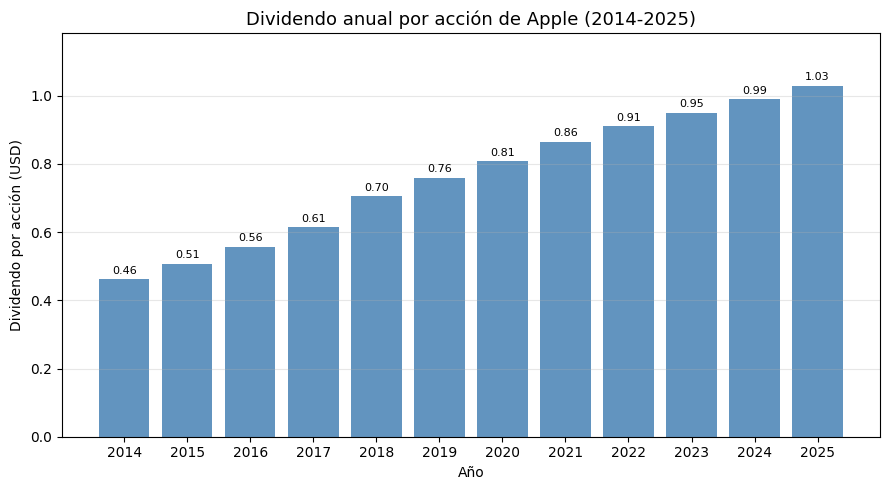

In [2]:
#| label: fig-dividendos
#| fig-cap: "Dividendo anual por acción de Apple, historial de más de cinco años."
#| echo: false
from src.yahoo_client import fetch_dividends

dividendos = fetch_dividends('AAPL', start='2014-01-01', end='2025-12-31')
div_anual = dividendos.groupby(dividendos.index.year).sum()

fig, ax = plt.subplots(figsize=(9, 5))
anios = div_anual.index.astype(str)
ax.bar(anios, div_anual.values, color='steelblue', alpha=0.85)
for xi, yi in zip(anios, div_anual.values):
    ax.text(xi, yi + 0.01, f'{yi:.2f}', ha='center', va='bottom', fontsize=8)
ax.set_title(f'Dividendo anual por acción de Apple ({div_anual.index[0]}-{div_anual.index[-1]})', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('Dividendo por acción (USD)')
ax.margins(y=0.15); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

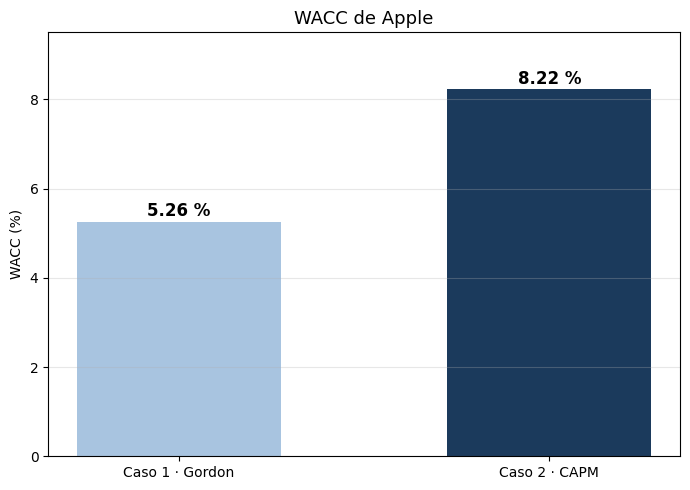

In [3]:
#| label: fig-wacc
#| fig-cap: "WACC de Apple según el método usado para estimar el costo del capital accionario."
#| echo: false
fig, ax = plt.subplots(figsize=(7, 5))
casos = ['Caso 1 · Gordon', 'Caso 2 · CAPM']
valores = [5.26, 8.22]
ax.bar(casos, valores, color=['#a8c4e0', '#1b3a5c'], width=0.55)
for c, v in zip(casos, valores):
    ax.text(c, v + 0.12, f'{v:.2f} %', ha='center', fontsize=12, fontweight='bold')
ax.set_title('WACC de Apple', fontsize=13)
ax.set_ylabel('WACC (%)'); ax.set_ylim(0, 9.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()